# Лабораторна 5 - Від NumPy до фреймворків: знайомство з PyTorch

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 5  
**Тема лабораторної:** Від NumPy до фреймворків: знайомство з PyTorch

## Цілі лабораторної

- Освоїти базові операції з тензорами PyTorch та їх зв'язок із NumPy-масивами
- Зрозуміти механізм автоматичного диференціювання (`autograd`) та граф обчислень
- Навчитися будувати нейронні мережі за допомогою `nn.Module` та `nn.Sequential`
- Освоїти стандартний цикл навчання PyTorch: `zero_grad → forward → loss → backward → step`
- Перенести клас `NeuralNetwork` з NumPy-реалізації (тиждень 4) на PyTorch, зберігаючи публічний API
- Зрозуміти різницю між логітами та ймовірностями та навчитися використовувати `F.cross_entropy`
- Порівняти ручну реалізацію backprop з автоматичним диференціюванням PyTorch

## Передумови

- Реалізація багатошарової нейронної мережі з NumPy (Тижні 3–4)
- Розуміння зворотного поширення помилки та Xavier-ініціалізації
- Базові знання Python ООП (класи, успадкування)
- Знайомство з логістичною регресією та категоріальною крос-ентропією

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

COLORS = ['#4C72B0', '#DD8452', '#55A868']
SEED = 42


---
## 1. - Основи PyTorch

### 1.1 Тензори

**Тензор** (`torch.Tensor`) - це основна структура даних PyTorch. Він аналогічний до `np.ndarray`, але також може зберігати інформацію про градієнти та виконуватись на GPU.

| Дія | NumPy | PyTorch |
|-----|-------|---------|
| Створити масив | `np.array([1, 2, 3])` | `torch.tensor([1, 2, 3])` |
| Нулі | `np.zeros((3, 4))` | `torch.zeros(3, 4)` |
| Випадковий | `np.random.randn(3, 4)` | `torch.randn(3, 4)` |
| Форма | `a.shape` | `t.shape` |
| Транспонування | `a.T` | `t.T` або `t.mT` |
| Матричне множення | `a @ b` | `t @ s` або `torch.mm(t, s)` |

In [21]:
# ── Creating tensors ─────────────────────────────────────────────────────────
t_from_list = torch.tensor([[1.0, 2.0, 3.0],
                             [4.0, 5.0, 6.0]])
print('From list:', t_from_list)
print('Shape:', t_from_list.shape)
print('dtype:', t_from_list.dtype)

# Zeros, ones, random
print('\nzeros(2,3):\n', torch.zeros(2, 3))
print('\nrandn(2,3):\n', torch.randn(2, 3))

From list: tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
dtype: torch.float32

zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

randn(2,3):
 tensor([[ 0.1498, -0.2089, -0.3870],
        [ 0.9912,  0.4679, -0.2049]])


In [22]:
# ── Bridge between NumPy and PyTorch ─────────────────────────────────────────
arr = np.array([[1.0, 2.0], [3.0, 4.0]])

# NumPy → Tensor (shared memory when on CPU!)
t = torch.from_numpy(arr)
print('from_numpy:', t)

# Tensor → NumPy
back = t.numpy()
print('back to numpy:', back)

# Modifying the NumPy array also changes the tensor (shared memory)
arr[0, 0] = 99.0
print('\nAfter modifying arr[0,0] = 99:')
print('arr:', arr)
print('tensor t:', t)   # also changed!

from_numpy: tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
back to numpy: [[1. 2.]
 [3. 4.]]

After modifying arr[0,0] = 99:
arr: [[99.  2.]
 [ 3.  4.]]
tensor t: tensor([[99.,  2.],
        [ 3.,  4.]], dtype=torch.float64)


In [23]:
# ── Tensor operations ────────────────────────────────────────────────────────
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print('a + b       =', a + b)
print('a * b       =', a * b)          # element-wise
print('a @ b       =', a @ b)          # dot product
print('a.sum()     =', a.sum())
print('a.mean()    =', a.mean())

# Matrix multiply
W = torch.randn(4, 3)   # (out, in)
x = torch.randn(3)
print('\nW shape:', W.shape, '  x shape:', x.shape)
print('W @ x shape:', (W @ x).shape)   # linear layer output

a + b       = tensor([11., 22., 33.])
a * b       = tensor([10., 40., 90.])
a @ b       = tensor(140.)
a.sum()     = tensor(6.)
a.mean()    = tensor(2.)

W shape: torch.Size([4, 3])   x shape: torch.Size([3])
W @ x shape: torch.Size([4])


> **✏️ Завдання 1.1** (inline): У клітинці нижче змініть форму тензора `x` з `(3,)` на `(3, 1)` (стовпець) і перевірте, як це впливає на результат множення. Підказка: спробуйте `x.unsqueeze(1)` або `x.reshape(3, 1)` і виведіть форму результату.

In [24]:
x_col = x.unsqueeze(1)   # TODO: try also x.reshape(3, 1)
print('x_col shape:', x_col.shape)
result = W @ x_col
print('W @ x_col shape:', result.shape)   # should be (4, 1)

x_col shape: torch.Size([3, 1])
W @ x_col shape: torch.Size([4, 1])


---
### 1.2 Автоматичне диференціювання (`autograd`)

Ключова перевага PyTorch перед NumPy - **autograd**: фреймворк автоматично обчислює похідні, відстежуючи операції у вигляді графу обчислень.

Граф будується «на льоту» (define-by-run): кожна операція над тензором із `requires_grad=True` записується у граф, а `.backward()` обходить його у зворотному напрямку за ланцюговим правилом.

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}$$

In [25]:
# ── Simple scalar gradient ───────────────────────────────────────────────────
# We want d/dx [x^2] at x = 3.0  =>  should equal 2*3 = 6
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2          # forward pass - PyTorch records this operation
y.backward()        # backward pass - computes dy/dx

print(f'x     = {x.item()}')
print(f'y     = x^2 = {y.item()}')
print(f'dy/dx = {x.grad.item()}   (expected: 2*x = {2*x.item():.1f})')

x     = 3.0
y     = x^2 = 9.0
dy/dx = 6.0   (expected: 2*x = 6.0)


In [26]:
# ── Gradient of a more complex expression ────────────────────────────────────
# L = sum((W @ x + b)^2)  -  a tiny linear layer with MSE
torch.manual_seed(SEED)
W = torch.randn(3, 2, requires_grad=True)
b = torch.zeros(3,    requires_grad=True)
x = torch.tensor([1.0, -1.0])

z = W @ x + b        # linear transformation
L = (z ** 2).sum()   # scalar loss
L.backward()

print('z  :', z.detach().numpy())
print('L  :', L.item())
print('dL/dW:\n', W.grad.numpy())
print('dL/db:', b.grad.numpy())

z  : [ 0.20788096  0.00412934 -0.9365281 ]
L  : 0.9203163981437683
dL/dW:
 [[ 0.41576192 -0.41576192]
 [ 0.00825867 -0.00825867]
 [-1.8730562   1.8730562 ]]
dL/db: [ 0.41576192  0.00825867 -1.8730562 ]


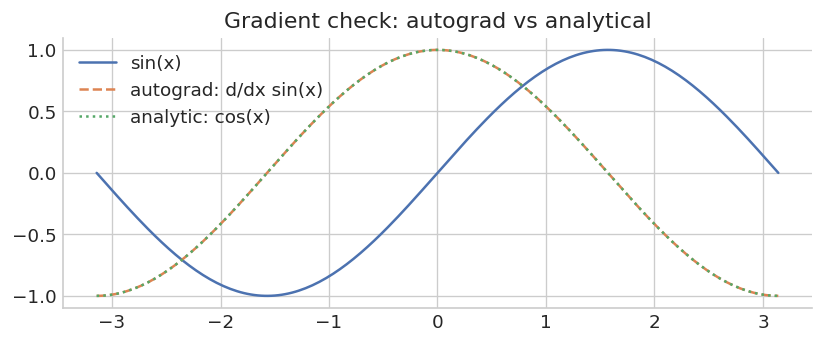

Max error: 5.96e-08


In [27]:
# ── Gradient check: autograd vs analytical ───────────────────────────────────
# f(x) = sin(x),  df/dx = cos(x)
x_vals = torch.linspace(-np.pi, np.pi, 200)
x_vals.requires_grad_(True)       # enable grad tracking in-place

y_vals = torch.sin(x_vals)
y_vals.sum().backward()           # .backward() requires scalar output

autograd_deriv  = x_vals.grad.detach().numpy()
analytic_deriv  = np.cos(x_vals.detach().numpy())

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x_vals.detach().numpy(), np.sin(x_vals.detach().numpy()),
        label='sin(x)', color=COLORS[0])
ax.plot(x_vals.detach().numpy(), autograd_deriv,
        label='autograd: d/dx sin(x)', color=COLORS[1], linestyle='--')
ax.plot(x_vals.detach().numpy(), analytic_deriv,
        label='analytic: cos(x)', color=COLORS[2], linestyle=':')
ax.set_title('Gradient check: autograd vs analytical')
ax.legend()
plt.tight_layout()
plt.show()

max_err = np.abs(autograd_deriv - analytic_deriv).max()
print(f'Max error: {max_err:.2e}')   # should be ~0

> **✏️ Завдання 1.2** (inline): Замість `torch.sin` спробуйте іншу функцію - наприклад, `torch.exp(x_vals)` або `x_vals**3 - 2*x_vals`. Порівняйте результат autograd із аналітичною похідною вручну.

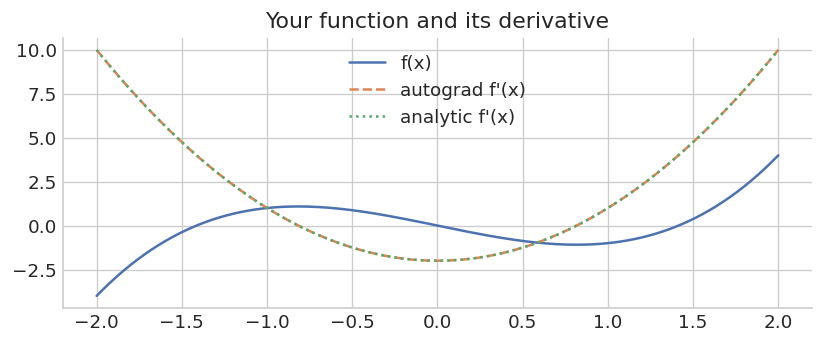

Max error: 0.00e+00


In [28]:
# TODO: replace sin with another function and verify gradient
x_vals2 = torch.linspace(-2.0, 2.0, 200, requires_grad=True)

# --- change the function below ---
f = x_vals2 ** 3 - 2 * x_vals2    # df/dx = 3x^2 - 2
# ---------------------------------

f.sum().backward()

x_np = x_vals2.detach().numpy()
autograd_d = x_vals2.grad.numpy()
analytic_d = 3 * x_np**2 - 2      # adjust this to match your function

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x_np, f.detach().numpy(),  label='f(x)',       color=COLORS[0])
ax.plot(x_np, autograd_d,          label="autograd f'(x)", color=COLORS[1], ls='--')
ax.plot(x_np, analytic_d,          label="analytic f'(x)", color=COLORS[2], ls=':')
ax.legend()
ax.set_title("Your function and its derivative")
plt.tight_layout()
plt.show()

print(f'Max error: {np.abs(autograd_d - analytic_d).max():.2e}')

---
### 1.3 Модулі, шари та оптимізатори

Шари нейронної мережі в PyTorch реалізуються як підкласи `nn.Module`. Це дозволяє:
- автоматично відстежувати параметри (`.parameters()`),
- зручно перемикатись між режимами навчання (`.train()`) та інференсу (`.eval()`),
- зберігати та завантажувати ваги (`.state_dict()`).

**Ключові вбудовані шари:**

| Шар | Опис |
|-----|------|
| `nn.Linear(in, out)` | Повнозв'язний лінійний шар: $y = xW^T + b$ |
| `nn.ReLU()` | Activation layer (можна і функцією: `F.relu(x)`) |
| `nn.Sequential(...)` | Контейнер: шари виконуються послідовно |
| `nn.ModuleList([...])` | Список модулів, параметри яких реєструються |

In [29]:
# ── Build a small net with nn.Sequential ─────────────────────────────────────
simple_net = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

print('Architecture:')
print(simple_net)

# Count trainable parameters
total_params = sum(p.numel() for p in simple_net.parameters())
print(f'\nTotal parameters: {total_params}')

# Named parameters
print('\nNamed parameters:')
for name, param in simple_net.named_parameters():
    print(f'  {name:20s}  shape={list(param.shape)}')

Architecture:
Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)

Total parameters: 131

Named parameters:
  0.weight              shape=[16, 4]
  0.bias                shape=[16]
  2.weight              shape=[3, 16]
  2.bias                shape=[3]


In [30]:
# ── Forward pass through the small net ───────────────────────────────────────
torch.manual_seed(SEED)
x_batch = torch.randn(8, 4)       # batch of 8 samples, 4 features each
logits = simple_net(x_batch)      # calls simple_net.forward(x_batch)
probs  = F.softmax(logits, dim=1) # convert to probabilities

print('logits shape :', logits.shape)    # (8, 3)
print('probs  shape :', probs.shape)     # (8, 3)
print('probs  (first 3 samples):\n', probs[:3].detach().numpy().round(4))
print('row sums:', probs.sum(dim=1).detach().numpy().round(6))

logits shape : torch.Size([8, 3])
probs  shape : torch.Size([8, 3])
probs  (first 3 samples):
 [[0.3968 0.1887 0.4145]
 [0.379  0.2458 0.3751]
 [0.3203 0.2383 0.4414]]
row sums: [1. 1. 1. 1. 1. 1. 1. 1.]


#### Функції втрат та оптимізатори

У PyTorch є два способи визначити функцію втрат:
- `nn.CrossEntropyLoss()` - об'єкт-шар (зберігає стан, якщо потрібно).
- `F.cross_entropy(logits, targets)` - функція, без стану.

**Важливо:** `F.cross_entropy` та `nn.CrossEntropyLoss` приймають **«сирі» логіти** (без softmax). Вони застосовують `log_softmax` та `nll_loss` всередині - це чисельно стабільніше, ніж розраховувати softmax вручну і потім логарифм.

**Оптимізатори** оновлюють параметри після кожного `.backward()`:

| Оптимізатор | Опис |
|-------------|------|
| `optim.SGD(params, lr)` | Звичайний стохастичний градієнтний спуск |
| `optim.SGD(..., momentum=0.9)` | SGD з імпульсом |
| `optim.Adam(params, lr)` | Adaptive moment estimation (рекомендований за замовчуванням) |

In [31]:
# ── Loss function example ─────────────────────────────────────────────────────
torch.manual_seed(SEED)
logits = torch.randn(5, 3)                     # 5 samples, 3 classes
targets = torch.tensor([0, 2, 1, 0, 2])        # true class labels

# F.cross_entropy expects raw logits, NOT softmax output
loss = F.cross_entropy(logits, targets)
print(f'Cross-entropy loss: {loss.item():.4f}')

# Verify: random logits should give loss ≈ log(3) ≈ 1.099
print(f'Expected for random (log 3): {np.log(3):.4f}')

Cross-entropy loss: 1.7564
Expected for random (log 3): 1.0986


In [32]:
# ── Optimizer: one step ───────────────────────────────────────────────────────
model = nn.Linear(4, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

x_in  = torch.randn(8, 4)
y_in  = torch.randint(0, 3, (8,))

# Before step: record weight values
w_before = model.weight.data.clone()

# Full training step
optimizer.zero_grad()                          # 1. clear old gradients
out  = model(x_in)                             # 2. forward pass
loss = F.cross_entropy(out, y_in)              # 3. compute loss
loss.backward()                                # 4. backprop
optimizer.step()                               # 5. update parameters

# After step: weights should have changed
w_after = model.weight.data.clone()
print(f'Loss:             {loss.item():.4f}')
print(f'Max weight change: {(w_after - w_before).abs().max().item():.6f}')

Loss:             1.0355
Max weight change: 0.010000


> **✏️ Завдання 1.3** (inline): Замість `torch.optim.Adam` спробуйте `torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)`. Чи зміниться крок ваг? Поясніть чому.

---
### 1.4 Цикл навчання: анатомія

Типовий цикл навчання в PyTorch завжди складається з одних і тих же п'яти кроків. Запам'ятайте їх - це фундамент для будь-якої мережі:

```
for epoch in range(n_epochs):
    optimizer.zero_grad()   # 1. очистити старі градієнти
    out  = model(X)         # 2. forward pass
    loss = criterion(out,y) # 3. обчислити втрату
    loss.backward()         # 4. backprop
    optimizer.step()        # 5. оновити параметри
```

Демонстрація: навчимо `nn.Sequential` розпізнавати три кластери в синтетичних даних.

In [33]:
# ── Toy dataset ───────────────────────────────────────────────────────────────
X_raw, y_raw = make_blobs(n_samples=300, centers=3,
                          cluster_std=1.5, random_state=SEED)
X_raw = StandardScaler().fit_transform(X_raw)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)

# Convert to tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.long)

print(f'Train: {X_tr_t.shape}  Test: {X_te_t.shape}')

Train: torch.Size([240, 2])  Test: torch.Size([60, 2])


In [34]:
# ── Define and train a simple Sequential net ─────────────────────────────────
torch.manual_seed(SEED)

toy_net = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),   # raw logits - softmax is inside cross_entropy
)

optimizer  = torch.optim.Adam(toy_net.parameters(), lr=0.01)
loss_curve = []

toy_net.train()
for epoch in range(500):
    optimizer.zero_grad()
    logits = toy_net(X_tr_t)
    loss   = F.cross_entropy(logits, y_tr_t)
    loss.backward()
    optimizer.step()
    loss_curve.append(loss.item())

# ── Evaluate ──────────────────────────────────────────────────────────────────
toy_net.eval()
with torch.no_grad():
    preds = toy_net(X_te_t).argmax(dim=1).numpy()

print(f'Test accuracy: {accuracy_score(y_te, preds):.4f}')

Test accuracy: 1.0000


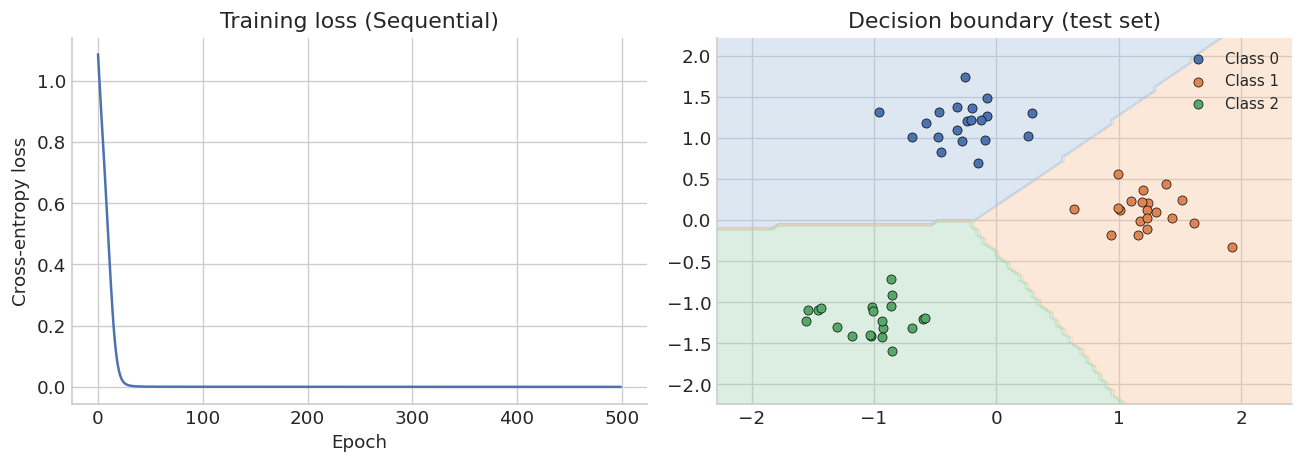

In [35]:
# ── Visualise training curve ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
axes[0].plot(loss_curve, color=COLORS[0], linewidth=1.5)
axes[0].set_title('Training loss (Sequential)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')

# Decision boundary
cmap = ListedColormap(['#A8C4E0', '#F5C6A0', '#A8D5B5'])
h = 0.05
x_min, x_max = X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5
y_min, y_max = X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_t = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

toy_net.eval()
with torch.no_grad():
    Z = toy_net(grid_t).argmax(dim=1).numpy().reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
for k, c in enumerate(COLORS):
    mask = y_te == k
    axes[1].scatter(X_te[mask, 0], X_te[mask, 1],
                    c=c, s=30, edgecolors='k', linewidths=0.4, label=f'Class {k}')
axes[1].set_title('Decision boundary (test set)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

#### `model.train()` vs `model.eval()`

Деякі компоненти (Dropout, BatchNorm) поводяться по-різному під час навчання та інференсу. Хороша практика - завжди перемикати режим явно:

- `model.train()` перед циклом навчання - вмикає dropout тощо.
- `model.eval()` перед predict/evaluate.
- `torch.no_grad()` блокує запис операцій у граф - економить пам'ять під час інференсу.

---
## 2. - `NeuralNetwork` на PyTorch

### 2.1 Від NumPy до PyTorch: порівняння архітектур

Настав час переписати клас `NeuralNetwork` з тижня 4 на PyTorch. Ціль - зберегти **той самий публічний інтерфейс**, щоб весь код з Homework 2 працював без змін.

#### Що змінюється «під капотом»

| Компонент | NumPy (тиждень 4) | PyTorch (тиждень 5) |
|-----------|-------------------|---------------------|
| Параметри | `params_['W1'], params_['b1'], ...` | `nn.ModuleList([nn.Linear(...)])` |
| Forward pass | Ручний цикл по шарах | Той самий цикл, але з `torch.Tensor` |
| Backprop | Ручна реалізація `backward()` | `loss.backward()` - автоматично |
| Оновлення ваг | Ручний `update_params(grads, lr)` | `optimizer.step()` |
| Ініціалізація | Xavier у `initialise_params()` | `_init_weights()` через `nn.init` |
| Функція втрат | `compute_loss()` вручну | `F.cross_entropy(logits, y)` |

#### Що **не** змінюється

- Сигнатура `__init__(layer_sizes, activations, random_state)`
- Методи `fit(X, y, lr, n_epochs, verbose)`, `predict(X)`, `predict_proba(X)`
- Атрибут `loss_curve_`
- Методи `get_params`, `set_params`, `score` (для сумісності зі sklearn)

#### Важливий нюанс: softmax + cross-entropy

`F.cross_entropy` об'єднує `log_softmax` та `nll_loss` в одну чисельно стабільну операцію. Тому у методі `fit` ми передаємо **сирі логіти** (вихід останнього лінійного шару **без** активації), а `softmax` застосовуємо лише в `predict_proba` - для отримання імовірностей при інференсі.

$$\text{cross\_entropy}(\text{logits}, y) = -\log \frac{e^{\text{logits}[y]}}{\sum_j e^{\text{logits}[j]}} = \text{NLLLoss}(\log\text{softmax}(\text{logits}), y)$$

#### Завдання для студента

За аналогією із `NeuralNetwork` з `nn_multiclass_student.py` створіть файл `nn_multiclass_pytorch_student.py` і адаптуйте клас нейронної мережі  для роботи з PyTorch.

Нижче наведено **скелет** класу зі всіма TODO - він точно відповідає структурі вашого файлу. Перенесіть зміни туди.

```python
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuralNetwork(nn.Module):

    def __init__(self, layer_sizes, activations, random_state=42):
        super().__init__()
        # keep the same attributes as before
        self.layer_sizes  = layer_sizes
        self.activations  = activations
        self.random_state = random_state
        self.loss_curve_  = []

        # TODO: build self.layers - an nn.ModuleList of nn.Linear layers
        # one nn.Linear(n_in, n_out) for each consecutive pair in layer_sizes

        self._init_weights()

    def _init_weights(self):
        # TODO: Xavier init - for each layer in self.layers:
        #   weights ~ N(0, sqrt(1/n_in)),  bias = 0
        # Use torch.manual_seed(self.random_state) for reproducibility
        pass

    def _apply_activation(self, z, name):
        # TODO: dispatch activation by name using F.relu, torch.tanh,
        # torch.sigmoid, F.softmax(z, dim=1)
        pass

    def forward(self, x):
        # TODO: pass x through each (linear, activation) pair
        # returns output probabilities - used in predict_proba
        pass

    def _logits(self, x):
        # TODO: same as forward but DO NOT apply the final activation
        # returns raw logits - used in fit() with F.cross_entropy
        pass

    def fit(self, X, y, lr=0.01, n_epochs=1000, verbose=True):
        self._init_weights()
        self.loss_curve_ = []
        # TODO:
        # 1. convert X (float32) and y (int64) to tensors
        # 2. create torch.optim.Adam optimizer
        # 3. call self.train()
        # 4. training loop - 5 steps: zero_grad / _logits / F.cross_entropy
        #    / backward / step - append loss.item() to self.loss_curve_
        # 5. print loss every 200 epochs if verbose
        return self

    def predict_proba(self, X):
        # TODO: self.eval(), torch.no_grad(), call forward(), return .numpy()
        pass

    def predict(self, X):
        proba = self.predict_proba(X)
        if proba.ndim == 1:
            return (proba >= 0.5).astype(int)
        return np.argmax(proba, axis=1)

    # sklearn compatibility - keep exactly as in Homework 2
    def get_params(self, deep=True): ...
    def set_params(self, **params): ...
    def score(self, X, y): ...
```

---
### 2.2 Тестування та верифікація

Після реалізації запустіть наступні комірки - вони відтворюють ті самі тести, що були у лабораторній роботі тижня 4.

In [36]:
import importlib
import nn_multiclass_pytorch_student as nn_mod    # edit this file
importlib.reload(nn_mod)
NeuralNetwork = nn_mod.NeuralNetwork
print('Module loaded.')

Module loaded.


In [37]:
# ── Test 1: instantiation and parameter count ─────────────────────────────────
model = NeuralNetwork(
    layer_sizes=[4, 8, 3],
    activations=['relu', 'softmax'],
    random_state=SEED,
)
print(model)

total = sum(p.numel() for p in model.parameters())
expected = (4*8 + 8) + (8*3 + 3)  # W1,b1,W2,b2
assert total == expected, f'Expected {expected} params, got {total}'
print(f'\nParameter count: {total}  ✓')

NeuralNetwork(
  (layers): ModuleList(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=3, bias=True)
  )
)

Parameter count: 67  ✓


In [38]:
# ── Test 2: forward pass - output shape and valid probabilities ───────────────
X_dummy = np.random.randn(10, 4).astype(np.float32)
proba = model.predict_proba(X_dummy)

assert proba.shape == (10, 3), f'Expected (10, 3), got {proba.shape}'
assert np.allclose(proba.sum(axis=1), 1.0, atol=1e-5), 'Rows must sum to 1'
assert (proba >= 0).all() and (proba <= 1).all(), 'Values must be in [0, 1]'
print('predict_proba shape and range: ✓')

predict_proba shape and range: ✓


In [39]:
# ── Test 3: predict returns integer labels in {0, 1, 2} ──────────────────────
preds = model.predict(X_dummy)
assert preds.shape == (10,), f'Expected (10,), got {preds.shape}'
assert set(preds).issubset({0, 1, 2}), f'Unexpected labels: {set(preds)}'
print('predict labels:', preds)
print('predict output: ✓')

predict labels: [1 1 1 2 1 2 0 0 2 2]
predict output: ✓


In [40]:
# ── Test 4: training reduces loss ────────────────────────────────────────────
X_toy, y_toy = make_blobs(n_samples=200, centers=3, random_state=SEED)
X_toy = StandardScaler().fit_transform(X_toy).astype(np.float32)

model_t = NeuralNetwork([2, 16, 3], ['relu', 'softmax'], random_state=SEED)
model_t.fit(X_toy, y_toy, lr=0.01, n_epochs=400, verbose=False)

assert len(model_t.loss_curve_) == 400, 'loss_curve_ length mismatch'
assert model_t.loss_curve_[-1] < model_t.loss_curve_[0], \
    'Loss did not decrease during training'
print(f'Initial loss: {model_t.loss_curve_[0]:.4f}')
print(f'Final loss:   {model_t.loss_curve_[-1]:.4f}  ✓')

Initial loss: 1.6536
Final loss:   0.0008  ✓


---
### 2.3 Навчання та оцінка

Повторимо оцінки з Лабораторної роботи 4 - цього разу з PyTorch-версією класу.

#### 2.3.1 Синтетичні дані (`make_blobs`)

In [41]:
# ── Dataset ───────────────────────────────────────────────────────────────────
X_b, y_b = make_blobs(n_samples=600, centers=3,
                      cluster_std=2.0, random_state=SEED)
X_b = StandardScaler().fit_transform(X_b).astype(np.float32)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=SEED, stratify=y_b
)

# ── Train ─────────────────────────────────────────────────────────────────────
model_b = NeuralNetwork(
    layer_sizes=[2, 32, 16, 3],
    activations=['relu', 'relu', 'softmax'],
    random_state=SEED,
)
model_b.fit(X_tr_b, y_tr_b, lr=0.01, n_epochs=600, verbose=True)

  Epoch     0  loss=1.3974
  Epoch   200  loss=0.0154
  Epoch   400  loss=0.0132
  Epoch   599  loss=0.0089


NeuralNetwork(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)

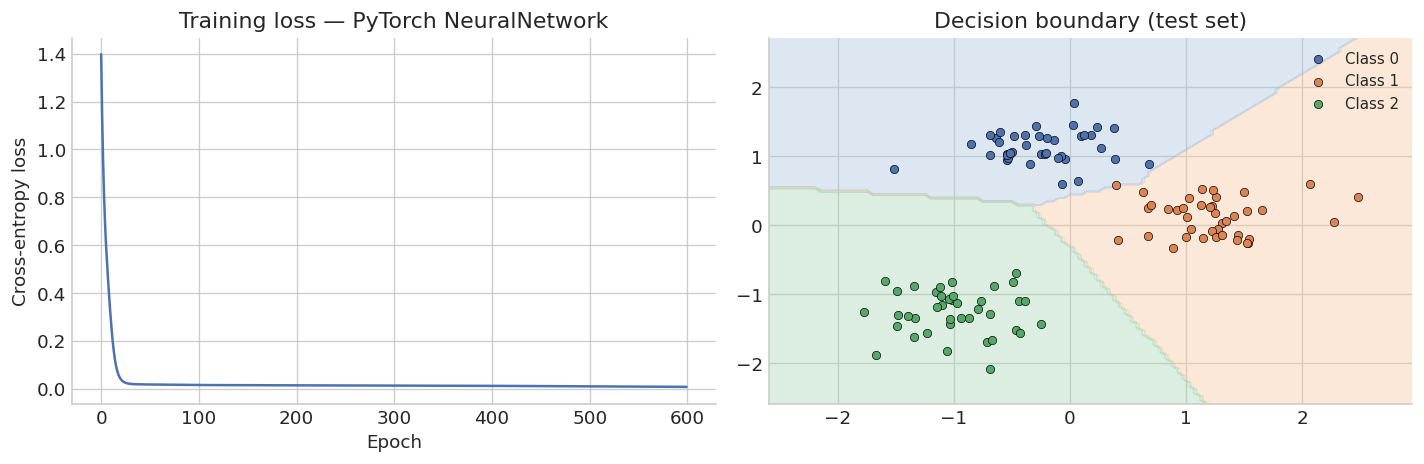

Test accuracy (make_blobs): 0.9917


In [42]:
# ── Loss curve and decision boundary ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(model_b.loss_curve_, color=COLORS[0], linewidth=1.5)
axes[0].set_title('Training loss - PyTorch NeuralNetwork')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')

# Decision boundary
cmap_bg = ListedColormap(['#A8C4E0', '#F5C6A0', '#A8D5B5'])
h = 0.05
x_min, x_max = X_b[:, 0].min() - 0.5, X_b[:, 0].max() + 0.5
y_min, y_max = X_b[:, 1].min() - 0.5, X_b[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z = model_b.predict(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
for k, c in enumerate(COLORS):
    mask = y_te_b == k
    axes[1].scatter(X_te_b[mask, 0], X_te_b[mask, 1],
                    c=c, s=25, edgecolors='k', linewidths=0.4, label=f'Class {k}')
axes[1].set_title('Decision boundary (test set)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

acc = accuracy_score(y_te_b, model_b.predict(X_te_b))
print(f'Test accuracy (make_blobs): {acc:.4f}')

#### 2.3.2 Реальні дані: Iris

In [43]:
# ── Iris dataset ──────────────────────────────────────────────────────────────
iris = load_iris()
X_ir = StandardScaler().fit_transform(iris.data).astype(np.float32)
y_ir = iris.target

X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(
    X_ir, y_ir, test_size=0.25, random_state=SEED, stratify=y_ir
)

# ── Train ─────────────────────────────────────────────────────────────────────
model_ir = NeuralNetwork(
    layer_sizes=[4, 64, 32, 3],
    activations=['relu', 'relu', 'softmax'],
    random_state=SEED,
)
model_ir.fit(X_tr_ir, y_tr_ir, lr=0.01, n_epochs=1000, verbose=True)

  Epoch     0  loss=1.1479
  Epoch   200  loss=0.0010
  Epoch   400  loss=0.0002
  Epoch   600  loss=0.0001
  Epoch   800  loss=0.0000
  Epoch   999  loss=0.0000


NeuralNetwork(
  (layers): ModuleList(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=3, bias=True)
  )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



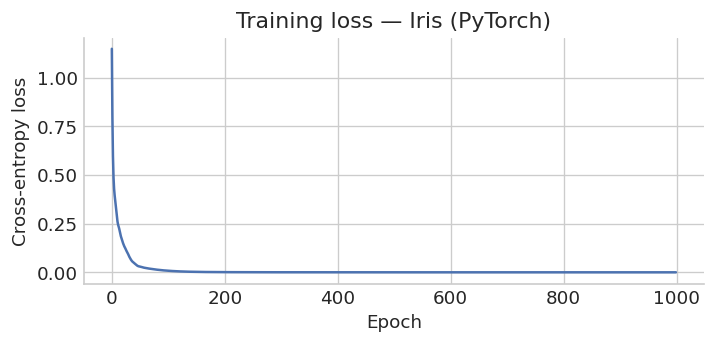

In [44]:
# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred_ir = model_ir.predict(X_te_ir)

print(classification_report(
    y_te_ir, y_pred_ir,
    target_names=iris.target_names
))

# Loss curve
plt.figure(figsize=(6, 3))
plt.plot(model_ir.loss_curve_, color=COLORS[0], linewidth=1.5)
plt.title('Training loss - Iris (PyTorch)')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.tight_layout()
plt.show()

#### 2.3.3 Порівняння: NumPy vs PyTorch

Перевіримо, чи PyTorch-версія дає результати, порівнянні з NumPy-версією тижня 4 на однакових гіперпараметрах.

NumPy test accuracy : 0.9211
PyTorch test accuracy: 0.9211


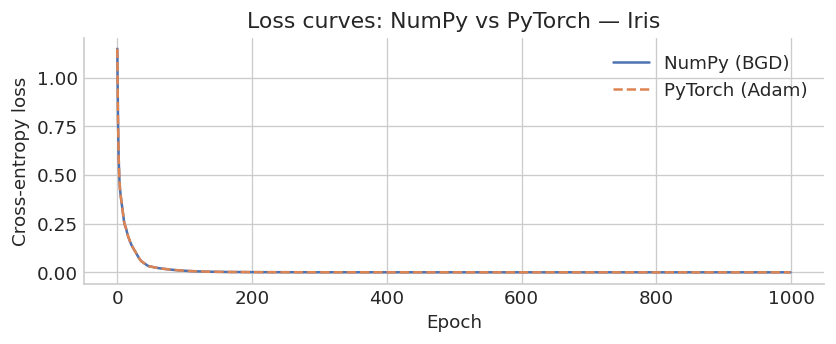

In [45]:
import nn_multiclass_student as nn_numpy   # Week 4 implementation
importlib.reload(nn_numpy)

# ── Train both on Iris ────────────────────────────────────────────────────────
ARCH = dict(layer_sizes=[4, 64, 32, 3],
            activations=['relu', 'relu', 'softmax'],
            random_state=SEED)
FIT  = dict(lr=0.01, n_epochs=1000, verbose=False)

m_numpy = nn_numpy.NeuralNetwork(**ARCH)
m_numpy.fit(X_tr_ir, y_tr_ir, **FIT)

m_torch = NeuralNetwork(**ARCH)
m_torch.fit(X_tr_ir, y_tr_ir, **FIT)

acc_numpy = accuracy_score(y_te_ir, m_numpy.predict(X_te_ir))
acc_torch = accuracy_score(y_te_ir, m_torch.predict(X_te_ir))

print(f'NumPy test accuracy : {acc_numpy:.4f}')
print(f'PyTorch test accuracy: {acc_torch:.4f}')

# ── Loss curve comparison ─────────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.plot(m_numpy.loss_curve_, label='NumPy (BGD)',   color=COLORS[0], lw=1.5)
plt.plot(m_torch.loss_curve_, label='PyTorch (Adam)', color=COLORS[1], lw=1.5, ls='--')
plt.title('Loss curves: NumPy vs PyTorch - Iris')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.tight_layout()
plt.show()

#### Sklearn-сумісність

Переконаємося, що `get_params`, `set_params` і `score` працюють - вони необхідні для Homework 2.

In [46]:
# ── sklearn compatibility check ───────────────────────────────────────────────
params = model_ir.get_params()
print('get_params():', params)

# score() after fit should equal accuracy_score
sk_score = model_ir.score(X_te_ir, y_te_ir)
print(f'score() = {sk_score:.4f}   (same as accuracy_score: {acc_torch:.4f})')
assert np.isclose(sk_score, accuracy_score(y_te_ir, model_ir.predict(X_te_ir)))
print('sklearn compatibility: ✓')

get_params(): {'layer_sizes': [4, 64, 32, 3], 'activations': ['relu', 'relu', 'softmax'], 'random_state': 42}
score() = 0.9211   (same as accuracy_score: 0.9211)
sklearn compatibility: ✓


---
## Підсумок

| Тема | Ключовий висновок |
|------|-------------------|
| **Тензори** | `torch.Tensor` - аналог `np.ndarray` із підтримкою градієнтів та GPU; пам'ять між NumPy і Tensor може бути спільною |
| **Autograd** | Граф обчислень будується автоматично при кожному forward pass; `.backward()` обходить його у зворотному напрямку |
| **`nn.Module`** | Базовий клас для всіх мереж; реєструє параметри, перемикає режими `train/eval` |
| **Цикл навчання** | П'ять фіксованих кроків: `zero_grad → forward → loss → backward → step` |
| **softmax + cross_entropy** | `F.cross_entropy` приймає логіти (без softmax) - чисельно стабільніше ніж застосовувати їх окремо |
| **NumPy → PyTorch** | Публічний API класу залишається незмінним; замінюється лише внутрішня реалізація |
